# Heart Failure Dataset Review

This notebook provides a clean, reproducible review of the heart failure dataset, including loading, inspection, preprocessing, exploratory analysis, and outcome comparison.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve

## Load dataset


In [5]:
DATA_PATH = 'Data_sets/heart_failure.csv'

df = pd.read_csv(DATA_PATH)

print(df.head())
print(df.info())

   Unnamed: 0  Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS  \
0           0   40   M           ATA        140          289          0   
1           1   49   F           NAP        160          180          0   
2           2   37   M           ATA        130          283          0   
3           3   48   F           ASY        138          214          0   
4           4   54   M           NAP        150          195          0   

  RestingECG  MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease  \
0     Normal    172              N      0.0       Up             0   
1     Normal    156              N      1.0     Flat             1   
2         ST     98              N      0.0       Up             0   
3     Normal    108              Y      1.5     Flat             1   
4     Normal    122              N      0.0       Up             0   

  heartdisease  
0   NOTfailure  
1      failure  
2   NOTfailure  
3      failure  
4   NOTfailure  
<class 'pandas.core.frame.

## Overview and column types


In [6]:
print('Data types:')
print(df.dtypes)

categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('Categorical columns:', categorical_columns)
print('Numerical columns:', numerical_columns)


Data types:
Unnamed: 0          int64
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
heartdisease       object
dtype: object
Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'heartdisease']
Numerical columns: ['Unnamed: 0', 'Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']


## Missing values and duplicates


In [7]:
print('Missing values by column:')
print(df.isnull().sum())

print('Duplicate rows:', df.duplicated().sum())

if df.duplicated().any():
    df = df.drop_duplicates().reset_index(drop=True)
    print('Dropped duplicate rows. New shape:', df.shape)
else:
    print('No duplicate rows found.')


Missing values by column:
Unnamed: 0        0
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
heartdisease      0
dtype: int64
Duplicate rows: 0
No duplicate rows found.


## Preprocessing


In [8]:
# Standardize categorical text values
for col in categorical_columns:
    df[col] = df[col].astype(str).str.lower().str.strip()

# Fill numeric missing values and scale
for col in numerical_columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

scaler = MinMaxScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

print('Preprocessing complete.')
print(df[numerical_columns].describe().T)


Preprocessing complete.
              count      mean       std  min       25%       50%       75%  \
Unnamed: 0    918.0  0.500000  0.289147  0.0  0.250000  0.500000  0.750000   
Age           918.0  0.520630  0.192502  0.0  0.387755  0.530612  0.653061   
RestingBP     918.0  0.661983  0.092571  0.0  0.600000  0.650000  0.700000   
Cholesterol   918.0  0.329684  0.181400  0.0  0.287313  0.369818  0.442786   
FastingBS     918.0  0.233115  0.423046  0.0  0.000000  0.000000  0.000000   
MaxHR         918.0  0.540911  0.179298  0.0  0.422535  0.549296  0.676056   
Oldpeak       918.0  0.396291  0.121201  0.0  0.295455  0.363636  0.465909   
HeartDisease  918.0  0.553377  0.497414  0.0  0.000000  1.000000  1.000000   

              max  
Unnamed: 0    1.0  
Age           1.0  
RestingBP     1.0  
Cholesterol   1.0  
FastingBS     1.0  
MaxHR         1.0  
Oldpeak       1.0  
HeartDisease  1.0  


## Exploratory data analysis


              count      mean       std  min       25%       50%       75%  \
Unnamed: 0    918.0  0.500000  0.289147  0.0  0.250000  0.500000  0.750000   
Age           918.0  0.520630  0.192502  0.0  0.387755  0.530612  0.653061   
RestingBP     918.0  0.661983  0.092571  0.0  0.600000  0.650000  0.700000   
Cholesterol   918.0  0.329684  0.181400  0.0  0.287313  0.369818  0.442786   
FastingBS     918.0  0.233115  0.423046  0.0  0.000000  0.000000  0.000000   
MaxHR         918.0  0.540911  0.179298  0.0  0.422535  0.549296  0.676056   
Oldpeak       918.0  0.396291  0.121201  0.0  0.295455  0.363636  0.465909   
HeartDisease  918.0  0.553377  0.497414  0.0  0.000000  1.000000  1.000000   

              max  
Unnamed: 0    1.0  
Age           1.0  
RestingBP     1.0  
Cholesterol   1.0  
FastingBS     1.0  
MaxHR         1.0  
Oldpeak       1.0  
HeartDisease  1.0  


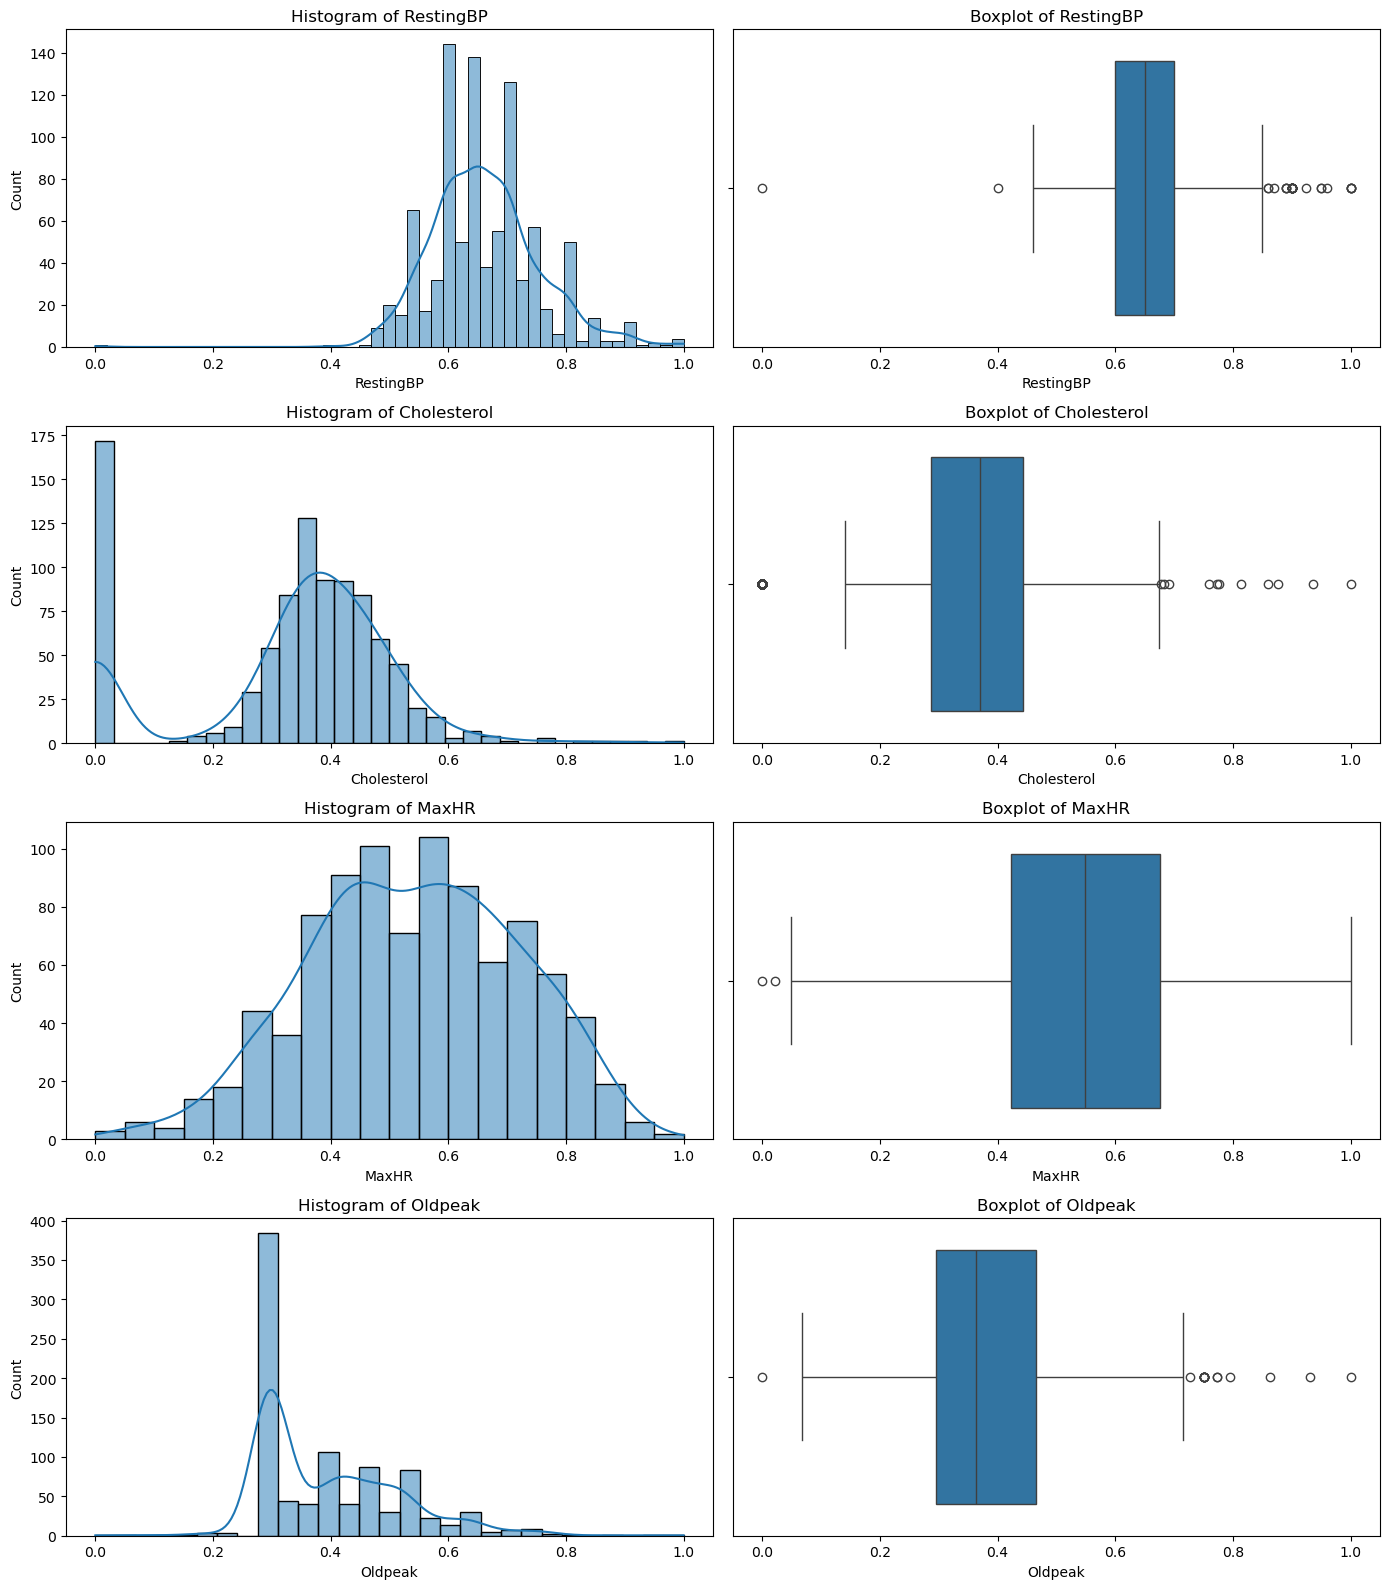

In [9]:
print(df.describe().T)

graph_columns = ['RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
fig, axs = plt.subplots(len(graph_columns), 2, figsize=(14, 4 * len(graph_columns)))
for i, col in enumerate(graph_columns):
    sns.histplot(df[col], kde=True, ax=axs[i, 0])
    axs[i, 0].set_title(f'Histogram of {col}')

    sns.boxplot(x=df[col], ax=axs[i, 1])
    axs[i, 1].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


### Categorical distributions


In [10]:
for col in categorical_columns:
    print(f'\n{col} distribution:')
    display(pd.DataFrame({
        'count': df[col].value_counts(),
        'percent': df[col].value_counts(normalize=True).mul(100).round(2)
    }))



Sex distribution:


,count,percent
Sex,,
m,725,78.98
f,193,21.02



ChestPainType distribution:


,count,percent
ChestPainType,,
asy,496,54.03
nap,203,22.11
ata,173,18.85
ta,46,5.01



RestingECG distribution:


...

,count,percent
ExerciseAngina,,
n,547,59.59
y,371,40.41



ST_Slope distribution:


,count,percent
ST_Slope,,
flat,460,50.11
up,395,43.03
down,63,6.86



heartdisease distribution:


,count,percent
heartdisease,,
failure,508,55.34
notfailure,410,44.66


## Correlation analysis


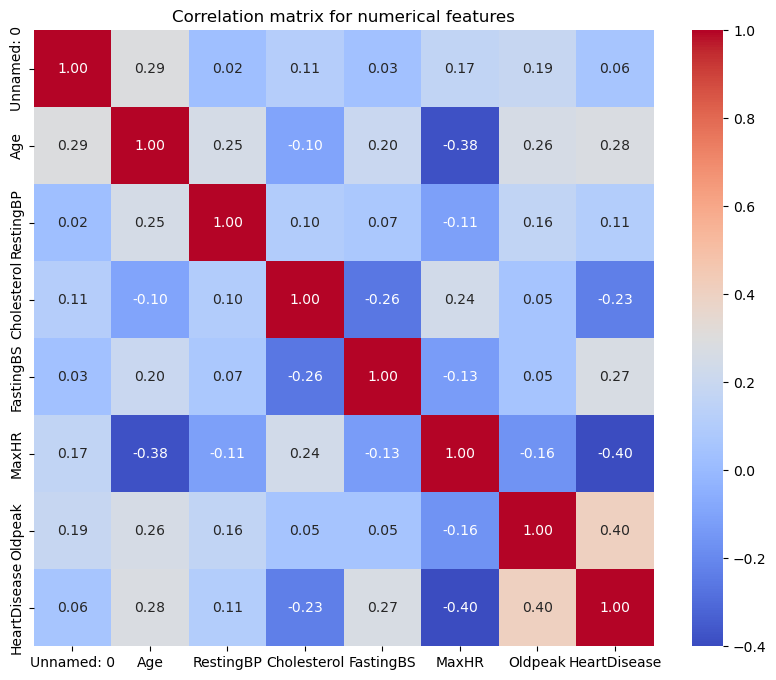

In [11]:
correlation_matrix = df[numerical_columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix for numerical features')
plt.show()


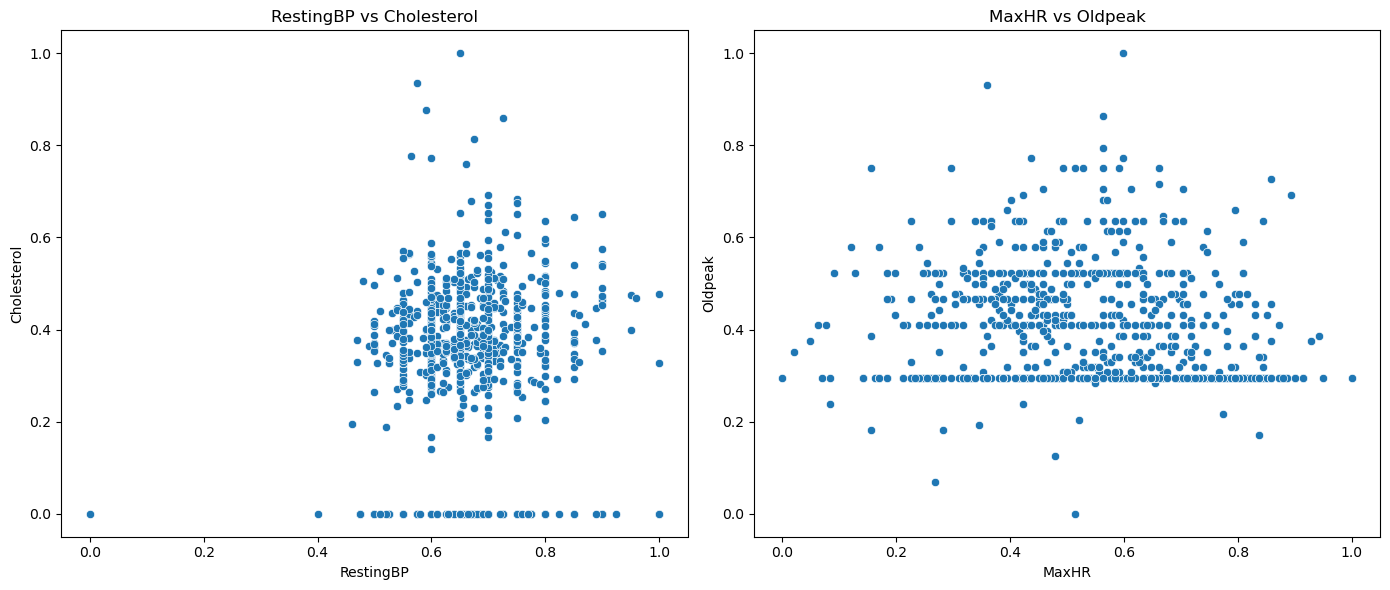

In [12]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=df['RestingBP'], y=df['Cholesterol'])
plt.title('RestingBP vs Cholesterol')

plt.subplot(1, 2, 2)
sns.scatterplot(x=df['MaxHR'], y=df['Oldpeak'])
plt.title('MaxHR vs Oldpeak')

plt.tight_layout()
plt.show()


## Heart disease outcome comparison


Target column: HeartDisease

HeartDisease by Sex:


HeartDisease,0.0,1.0
Sex,,
f,74.09,25.91
m,36.83,63.17


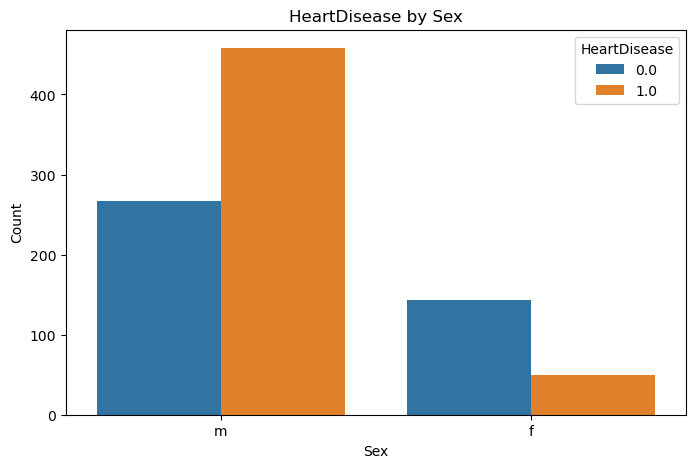


HeartDisease by ChestPainType:


HeartDisease,0.0,1.0
ChestPainType,,
asy,20.97,79.03
ata,86.13,13.87
nap,64.53,35.47
ta,56.52,43.48


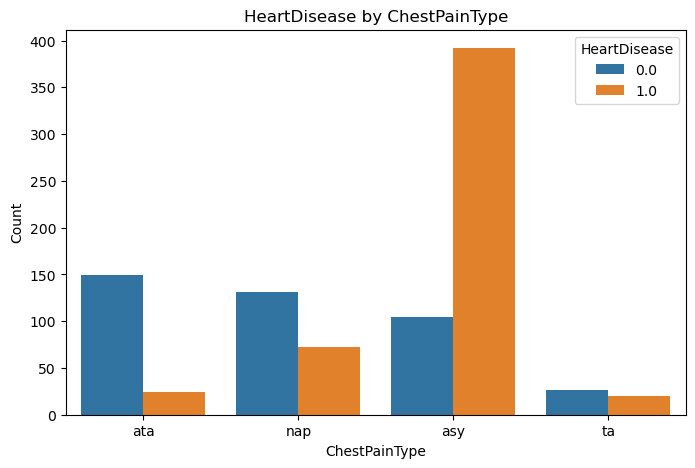


HeartDisease by RestingECG:


HeartDisease,0.0,1.0
RestingECG,,
lvh,43.62,56.38
normal,48.37,51.63
st,34.27,65.73


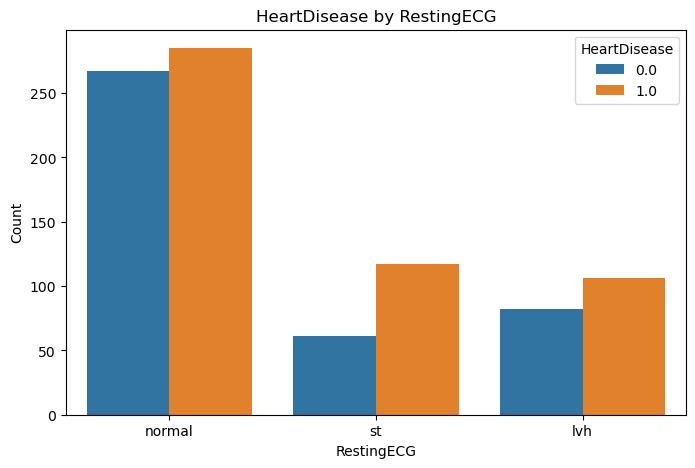


HeartDisease by ExerciseAngina:


HeartDisease,0.0,1.0
ExerciseAngina,,
n,64.90,35.10
y,14.82,85.18


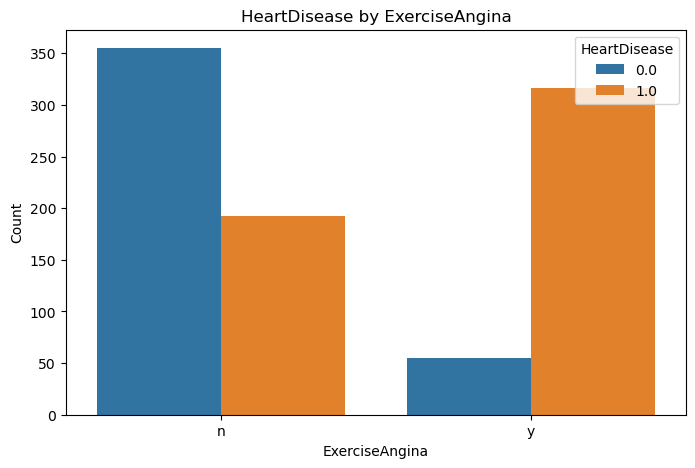


HeartDisease by ST_Slope:


HeartDisease,0.0,1.0
ST_Slope,,
down,22.22,77.78
flat,17.17,82.83
up,80.25,19.75


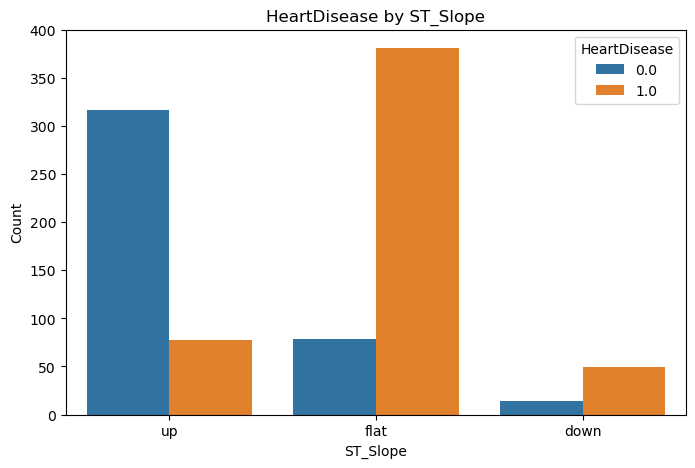


HeartDisease by heartdisease:


HeartDisease,0.0,1.0
heartdisease,,
failure,0.0,100.0
notfailure,100.0,0.0


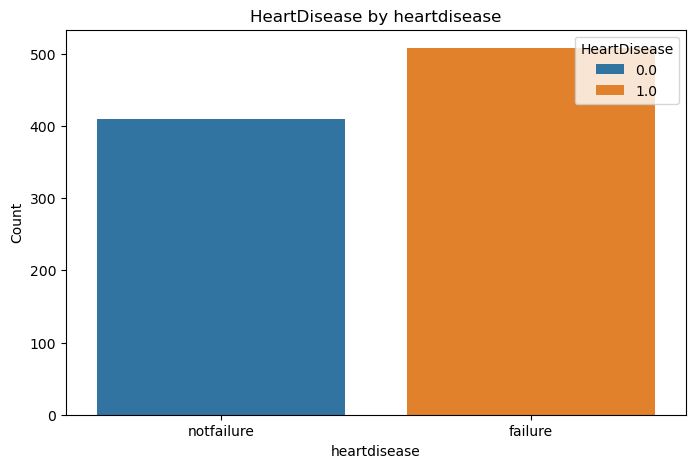

In [13]:
if 'HeartDisease' in df.columns:
    target_column = 'HeartDisease'
elif 'heartdisease' in df.columns:
    target_column = 'heartdisease'
else:
    raise ValueError('Target column not found')

print('Target column:', target_column)
df[target_column] = df[target_column].astype(str).str.lower().str.strip()

for col in categorical_columns:
    if col == target_column or col not in df.columns:
        continue
    crosstab = pd.crosstab(df[col], df[target_column], normalize='index') * 100
    print(f'\n{target_column} by {col}:')
    display(crosstab.round(2))
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df[col], hue=df[target_column])
    plt.title(f'{target_column} by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title=target_column, loc='upper right')
    plt.show()


## Conclusion and next steps

- The dataset is loaded cleanly with standardized categorical labels and scaled numeric features.
- The notebook includes clear EDA sections for both numerical and categorical variables.
- Heart disease outcome comparisons are now more consistent and interpretable.

Next steps:
1. Add a model training section for classification.
2. Add feature importance or SHAP analysis.
3. Add a summary section that highlights the most important findings.


In [ ]:
df.to_csv('Data_sets/filtered_data.csv', index=False)
print('Saved filtered dataset to Data_sets/filtered_data.csv')
